# Pressing metrics: Barça vs Atlético (first half)

Standalone stats notebook. It reads the folder written by **section 16 of the build-up pressure notebook** (`pressure_stats_input/`), so no video and no re-detection are needed.

**Run order:** run the setup cell once, then any metric cell on its own (each metric cell only needs the setup cell).

| # | Metric | Main output |
|---|---|---|
| 1 | Average defensive line depth per team | m from own goal |
| 2 | Pressing intensity | % of out-of-possession time spent pressing |
| 3 | Pressure by pitch zone (middle and attacking third) | counts and % |
| 4 | Pressure heatmap | where each team's pressure is concentrated |
| 5 | Pressing intensity over time | 5-minute bins, low-sample bins masked |
| 6 | PPDA | passes allowed per defensive action, own third excluded |
| 7 | Time-to-press after losing the ball | mean / median / min / max within 10 s |
| 8 | Pass success rate, under pressure vs not | by team |
| 9 | Defensive line height | last-1 and last-3 defenders, IQR outlier removal |
| 10 | Team compactness out of possession | depth, width, area |
| 11 | Compactness while pressing vs not | depth, width, area |
| 12 | Third x channel grid | where each team's pressure happens (3 x 3) |
| 13 | Zone intensity per time in zone | % of the time the ball is in a zone that the team is pressing |
| 14 | Press-to-regain rate | % of pressing episodes that end with the team getting the ball back within 5 s |
| 15 | Pressing time per player | seconds and share of the team's pressing |
| 16 | Where each player presses | third x channel per player |

(8b is a check on section 8.) Sections 15 and 16 need `defenders.parquet` from the export; the rest need only frames, positions, spells and roster.

**Definitions inherited from the build-up notebook**
- *Pressing / under pressure* (`frames.under_pressure`): at least one defender within 5 m of the ball carrier who is either within 2 m or closing at 1.5 m/s or more, held for 0.4 s in a row. It is a per-frame flag for the **defending** team (`def_team`).
- *Out of possession* = frames of the export in which the team is `def_team`. Stoppages are already excluded by the possession spells.
- Zones are thirds of the pitch in the **pressing team's own attacking direction** (own third 0-35 m, middle 35-70 m, attacking 70-105 m, measured from the pressing team's own goal).

## Setup: load the export, parameters, helpers

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

# ------------------------------------------------------------------ where the export lives (written by section 16 of the build-up notebook)
EXPORT_DIR_OVERRIDE = None        # put a path here to skip the search below
_CANDIDATES = [
    Path("C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project/new/press/buildup_output/pressure_stats_input"),
    Path.cwd() / "buildup_output" / "pressure_stats_input",
    Path.cwd() / "pressure_stats_input",
]
EXPORT_DIR = Path(EXPORT_DIR_OVERRIDE) if EXPORT_DIR_OVERRIDE else next((p for p in _CANDIDATES if (p / "meta.json").exists()), None)
assert EXPORT_DIR is not None and (EXPORT_DIR / "meta.json").exists(), (
    "pressure_stats_input/ not found. Run section 16 of the build-up notebook first, or set EXPORT_DIR_OVERRIDE above.")

# ------------------------------------------------------------------ parameters of THIS notebook
PRM = dict(
    # metric 5: time bins
    BIN_MINUTES=5, MIN_BIN_FRAMES=500,        # a team/bin with fewer out-of-possession frames than this is masked (500 frames = 20 s)
    # metric 9 and 10: outlier removal / shape
    IQR_MULT=1.5,
    BACK_N=3, FRONT_N=3, MIN_PLAYERS_FOR_SHAPE=6,
    # metric 7: time-to-press
    TTP_WINDOW_SEC=10.0,                      # search window after the turnover
    TTP_GRACE_SEC=0.0,                        # set to 1.0 to ignore pressure in the first second (the player who just lost it is still next to the new carrier)
    # metrics 6 and 8: pass detection from carrier transitions (same rules as the first pressure notebook)
    MIN_PASS_DISTANCE_M=3.0,                  # shorter carrier-to-carrier distance = duel / tackle, not a pass
    MAX_RECEPTION_GAP_SEC=2.0,                # longer gap = ball out of play, skipped
    MIN_HOLD_FRAMES_PASS=2,                   # ignores single-frame carrier flicker
    PRESSURE_LOOKBACK_SEC=1.0,                # a pass is "under pressure" if the opponent was pressing at any frame in this window before release
    # metric 4: heatmap
    HEATMAP_GRIDSIZE=25, BOUNDS_TOL_M=2.0,
    # metrics 12-16
    MIN_CELL_FRAMES=100,                      # an intensity cell with fewer ball-in-cell frames than this is greyed out (100 frames = 4 s)
    EPISODE_GAP_FRAMES=5, MIN_EPISODE_SEC=0.5,   # pressing episode: runs of pressing frames, gaps up to 5 frames bridged, at least 0.5 s
    REGAIN_WINDOW_SEC=5.0,                    # regain = pressing team has the ball within this long after the episode ends
    MIN_PLAYER_PRESS_FRAMES=50,               # players with fewer pressing frames are listed but not read into (50 frames = 2 s)
)
LEFT_IS_LOW_Y_ATT = True                      # from the build-up notebook's roster cell: in a team's attacking frame, low y = its LEFT side (flip if mirrored)

# ------------------------------------------------------------------ load
for _n in ["frames", "positions", "spells", "roster"]:
    assert (EXPORT_DIR / f"{_n}.parquet").exists(), f"{_n}.parquet is missing in {EXPORT_DIR}"
meta = json.loads((EXPORT_DIR / "meta.json").read_text())
frames = pd.read_parquet(EXPORT_DIR / "frames.parquet")
positions = pd.read_parquet(EXPORT_DIR / "positions.parquet")
spells = pd.read_parquet(EXPORT_DIR / "spells.parquet")
roster = pd.read_parquet(EXPORT_DIR / "roster.parquet")

_need = dict(frames=["frame_idx", "spell_id", "poss_team", "def_team", "under_pressure", "n_pressing", "carrier_track_id", "x", "y"],
             positions=["frame_idx", "track_id", "team", "role", "x", "y"],
             spells=["spell_id", "team", "start_frame", "end_frame", "start_type", "duration_sec"],
             roster=["track_id", "team", "role"])
for _n, _df in [("frames", frames), ("positions", positions), ("spells", spells), ("roster", roster)]:
    _miss = [c for c in _need[_n] if c not in _df.columns]
    assert not _miss, f"{_n}: columns missing {_miss} (found {list(_df.columns)})"

FPS = int(meta["fps"])
PITCH_LENGTH, PITCH_WIDTH = float(meta["pitch_length"]), float(meta["pitch_width"])
TEAM_NAMES = {int(k): str(v) for k, v in meta["team_names"].items()}
ATT_POS = {int(k): bool(v) for k, v in meta["team_attacks_positive_x"].items()}     # team attacks towards +x
THIRD_1_M = float(meta["params"].get("THIRD_1_M", PITCH_LENGTH / 3))
THIRD_2_M = float(meta["params"].get("THIRD_2_M", 2 * PITCH_LENGTH / 3))
TEAMS = sorted(TEAM_NAMES)
ZONES = ["own_third", "middle_third", "attacking_third"]
F = lambda sec: int(round(sec * FPS))
name = lambda t: TEAM_NAMES.get(int(t), str(t))

# ------------------------------------------------------------------ clean types
frames = frames.sort_values("frame_idx").drop_duplicates("frame_idx").reset_index(drop=True)
frames["poss_team"] = frames["poss_team"].astype(int)
frames["def_team"] = frames["def_team"].astype(int)
frames["under_pressure"] = frames["under_pressure"].astype(bool)
positions["team"] = positions["team"].astype(int)
positions["track_id"] = positions["track_id"].astype(int)
spells["team"] = spells["team"].astype(int)
roster["team"] = roster["team"].astype(int)

# ------------------------------------------------------------------ helpers
def team_frame(x, y, team):
    """Pitch metres -> the given team's own attacking frame (x = metres from that team's own goal, always attacking towards +x)."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    team = np.broadcast_to(np.asarray(team), x.shape)
    attacks_pos = pd.Series(team).map(ATT_POS).to_numpy(dtype=bool)
    return np.where(attacks_pos, x, PITCH_LENGTH - x), np.where(attacks_pos, y, PITCH_WIDTH - y)

def zone_of(x_own_frame):
    return pd.cut(pd.Series(np.asarray(x_own_frame, dtype=float)), [-np.inf, THIRD_1_M, THIRD_2_M, np.inf],
                  labels=ZONES, right=False)

def wilson(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = k / n; den = 1 + z ** 2 / n
    c = (p + z ** 2 / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return c - h, c + h

def iqr_clean(df, col, by="team", mult=None):
    """Drop values outside [Q1 - mult*IQR, Q3 + mult*IQR], computed separately for each team."""
    mult = PRM["IQR_MULT"] if mult is None else mult
    parts = []
    for _, g in df.groupby(by):
        q1, q3 = g[col].quantile([0.25, 0.75]); iqr = q3 - q1
        parts.append(g[(g[col] >= q1 - mult * iqr) & (g[col] <= q3 + mult * iqr)])
    return pd.concat(parts)

def draw_pitch(ax, lw=1.2):
    ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", linewidth=lw))
    ax.axvline(PITCH_LENGTH / 2, color="black", linewidth=0.6)
    ax.add_patch(patches.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", linewidth=0.6))
    bd, bw = 16.5, 40.3
    ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - bw) / 2), bd, bw, fill=False, color="black", linewidth=0.6))
    ax.add_patch(patches.Rectangle((PITCH_LENGTH - bd, (PITCH_WIDTH - bw) / 2), bd, bw, fill=False, color="black", linewidth=0.6))
    for gx in (THIRD_1_M, THIRD_2_M):
        ax.axvline(gx, color="grey", linewidth=0.5, linestyle=":")
    ax.set_xlim(-3, PITCH_LENGTH + 3); ax.set_ylim(-3, PITCH_WIDTH + 3); ax.set_aspect("equal"); ax.axis("off")

_CACHE = {}
def cached(fn):
    """Each derived table is built once, on first use, so every metric cell can be run on its own."""
    def wrap():
        if fn.__name__ not in _CACHE:
            _CACHE[fn.__name__] = fn()
        return _CACHE[fn.__name__]
    wrap.__name__ = fn.__name__
    return wrap

@cached
def defending_positions():
    """Outfield players of the DEFENDING team in every frame (= the team out of possession), with distance from their own goal."""
    pl = positions[positions["role"] == "player"]
    d = pl.merge(frames[["frame_idx", "def_team", "under_pressure"]], on="frame_idx", how="inner")
    d = d[d["team"] == d["def_team"]].copy()
    d["dist_own_goal"] = np.clip(team_frame(d["x"], d["y"], d["team"])[0], 0, PITCH_LENGTH)
    return d

@cached
def line_frames():
    """Per frame and out-of-possession team: height of the last defender (last1) and mean of the last three (last3), m from own goal."""
    d = defending_positions().sort_values(["frame_idx", "team", "dist_own_goal"])
    keys = ["frame_idx", "team"]
    rank = d.groupby(keys).cumcount()
    last1 = d.loc[rank == 0].set_index(keys)["dist_own_goal"].rename("last1")
    g3 = d.loc[rank < 3].groupby(keys)["dist_own_goal"].agg(["mean", "size"])
    last3 = g3.loc[g3["size"] == 3, "mean"].rename("last3")
    out = pd.concat([last1, last3], axis=1).reset_index()
    return out.merge(frames[["frame_idx", "under_pressure"]], on="frame_idx", how="left")

@cached
def team_shape():
    """Per frame and out-of-possession team: back line, front line, depth, IQR-trimmed width and area (depth x width)."""
    keys = ["frame_idx", "team"]
    d = defending_positions().sort_values(keys + ["dist_own_goal"]).copy()
    gb = d.groupby(keys)
    d["rank"] = gb.cumcount()
    d["n"] = gb["dist_own_goal"].transform("size")
    d = d[d["n"] >= PRM["MIN_PLAYERS_FOR_SHAPE"]]
    back = d[d["rank"] < PRM["BACK_N"]].groupby(keys)["dist_own_goal"].mean().rename("back_line_m")
    front = d[d["rank"] >= d["n"] - PRM["FRONT_N"]].groupby(keys)["dist_own_goal"].mean().rename("front_line_m")
    q = d.groupby(keys)["y"].quantile([0.25, 0.75]).unstack()
    q.columns = ["q1", "q3"]
    d = d.join(q, on=keys)
    iqr = d["q3"] - d["q1"]; m = PRM["IQR_MULT"]
    kept = d[(d["y"] >= d["q1"] - m * iqr) & (d["y"] <= d["q3"] + m * iqr)]
    w = kept.groupby(keys)["y"].agg(["max", "min"])
    width = (w["max"] - w["min"]).rename("width_m")
    shape = pd.concat([back, front, width], axis=1).dropna().reset_index()
    shape["depth_m"] = shape["front_line_m"] - shape["back_line_m"]
    shape["area_m2"] = shape["depth_m"] * shape["width_m"]
    return shape.merge(frames[["frame_idx", "under_pressure"]], on="frame_idx", how="left")

@cached
def detect_passes():
    """Passes and defensive actions from carrier transitions (same rules as the first pressure notebook, built on the export tables).
    Returns dict(passes, actions, info). passes: completed / intercepted attempts. actions: interceptions and tackles by the defending team."""
    team_of = roster.drop_duplicates("track_id").set_index("track_id")["team"].to_dict()
    car = frames.dropna(subset=["carrier_track_id"])[["frame_idx", "carrier_track_id"]].copy()
    car["carrier_track_id"] = car["carrier_track_id"].astype(int)
    car["team"] = car["carrier_track_id"].map(team_of)
    n_no_team = int(car["team"].isna().sum())
    car = car.dropna(subset=["team"]); car["team"] = car["team"].astype(int)
    max_gap = F(PRM["MAX_RECEPTION_GAP_SEC"])
    new_run = (car["carrier_track_id"] != car["carrier_track_id"].shift()) | (car["frame_idx"].diff() > max_gap)
    car["run_id"] = new_run.cumsum()
    runs = (car.groupby("run_id").agg(track_id=("carrier_track_id", "first"), team=("team", "first"),
                                      start_frame=("frame_idx", "first"), end_frame=("frame_idx", "last"), n_frames=("frame_idx", "count"))
            .reset_index(drop=True))
    runs = runs[runs["n_frames"] >= PRM["MIN_HOLD_FRAMES_PASS"]].reset_index(drop=True)

    a, b = runs.iloc[:-1].reset_index(drop=True), runs.iloc[1:].reset_index(drop=True)
    pr_ = pd.DataFrame(dict(passer_track_id=a["track_id"], passer_team=a["team"], release_frame=a["end_frame"],
                            receiver_track_id=b["track_id"], receiver_team=b["team"], reception_frame=b["start_frame"]))
    pr_["gap_frames"] = pr_["reception_frame"] - pr_["release_frame"]
    n_pairs_all = len(pr_)
    pr_ = pr_[pr_["gap_frames"] <= max_gap]
    n_pairs_gap_ok = len(pr_)

    pos_k = positions[["frame_idx", "track_id", "x", "y", "role"]].drop_duplicates(["frame_idx", "track_id"])
    pr_ = pr_.merge(pos_k[["frame_idx", "track_id", "x", "y"]].rename(columns=dict(frame_idx="release_frame", track_id="passer_track_id", x="release_x", y="release_y")),
                    on=["release_frame", "passer_track_id"], how="left")
    pr_ = pr_.merge(pos_k.rename(columns=dict(frame_idx="reception_frame", track_id="receiver_track_id", x="receive_x", y="receive_y", role="receiver_role")),
                    on=["reception_frame", "receiver_track_id"], how="left")
    n_missing_pos = int(pr_[["release_x", "receive_x"]].isna().any(axis=1).sum())
    pr_ = pr_.dropna(subset=["release_x", "release_y", "receive_x", "receive_y"]).copy()

    same = (pr_["passer_team"] == pr_["receiver_team"]).to_numpy()
    n_gk = int((~same & (pr_["receiver_role"] == "goalkeeper").to_numpy()).sum())
    pr_ = pr_[~(~same & (pr_["receiver_role"] == "goalkeeper").to_numpy())].copy()      # keeper save / claim: not a pressing action
    same = (pr_["passer_team"] == pr_["receiver_team"]).to_numpy()
    pr_["dist_m"] = np.hypot(pr_["receive_x"] - pr_["release_x"], pr_["receive_y"] - pr_["release_y"])
    short = (pr_["dist_m"] < PRM["MIN_PASS_DISTANCE_M"]).to_numpy()

    tackles = pr_[~same & short]
    inter = pr_[~same & ~short]
    acts = pd.concat([tackles.assign(action_type="tackle"), inter.assign(action_type="interception")])
    actions = pd.DataFrame(dict(defending_team=acts["receiver_team"], attacking_team=acts["passer_team"], action_type=acts["action_type"],
                                frame=acts["release_frame"], x=acts["release_x"], y=acts["release_y"])).reset_index(drop=True)
    passes = pr_[~short].copy()
    passes["outcome"] = np.where(passes["passer_team"] == passes["receiver_team"], "completed", "intercepted")
    passes = passes.reset_index(drop=True)
    info = dict(carrier_runs=len(runs), transitions=n_pairs_all, within_gap=n_pairs_gap_ok, missing_positions=n_missing_pos,
                gk_claims_excluded=n_gk, carriers_without_team=n_no_team)
    return dict(passes=passes, actions=actions, info=info)

# ------------------------------------------------------------------ helpers for the zone / channel / player metrics (12-16)
CH_ORDER = ["y_low", "centre", "y_high"]
CH_LABEL = {"y_low": "left" if LEFT_IS_LOW_Y_ATT else "right", "centre": "centre", "y_high": "right" if LEFT_IS_LOW_Y_ATT else "left"}
ZONE_SHORT = {"own_third": "own", "middle_third": "mid", "attacking_third": "att"}

def channel_of(y_own_frame):
    return pd.cut(pd.Series(np.asarray(y_own_frame, dtype=float)), [-np.inf, PITCH_WIDTH / 3, 2 * PITCH_WIDTH / 3, np.inf],
                  labels=CH_ORDER, right=False)

def draw_grid(ax, M, texts, title, cmap="Greens", vmax=None):
    """3 x 3 grid: columns = own / middle / attacking third, rows = channels (lowest y at the bottom, like the pitch maps). NaN cells are grey."""
    cm = plt.get_cmap(cmap).copy(); cm.set_bad("#e6e6e6")
    ax.imshow(np.ma.masked_invalid(np.asarray(M, dtype=float)), origin="lower", cmap=cm, aspect="auto", vmin=0, vmax=vmax)
    arr = np.asarray(M, dtype=float)
    top = vmax if vmax is not None else (np.nanmax(arr) if np.isfinite(arr).any() else 1.0)
    for i in range(3):
        for j in range(3):
            dark = np.isfinite(arr[i, j]) and top > 0 and arr[i, j] / top > 0.6          # white text on dark cells
            ax.text(j, i, texts[i][j], ha="center", va="center", fontsize=9, color="white" if dark else "black")
    ax.set_xticks(range(3)); ax.set_xticklabels(["own\nthird", "middle\nthird", "attacking\nthird"], fontsize=8)
    ax.set_yticks(range(3)); ax.set_yticklabels([CH_LABEL[c] for c in CH_ORDER], fontsize=8)
    ax.set_title(title, fontsize=10)

@cached
def frames_zoned():
    """frames + where the pressed ball is, in the PRESSING (defending) team's attacking frame: press_x / press_y, third (zone) and channel."""
    fz = frames.copy()
    fz["press_x"], fz["press_y"] = team_frame(fz["x"], fz["y"], fz["def_team"])
    fz["zone"] = zone_of(fz["press_x"]).to_numpy()
    fz["channel"] = channel_of(fz["press_y"]).to_numpy()
    return fz

@cached
def player_press_frames():
    """One row per defending outfield player and frame, with his instantaneous press flag, the team-level pressing flag and where the ball is."""
    path = EXPORT_DIR / "defenders.parquet"
    assert path.exists(), "defenders.parquet is missing in the export folder (section 16 of the build-up notebook writes it)."
    d = pd.read_parquet(path)
    assert {"frame_idx", "track_id", "is_press"} <= set(d.columns), f"defenders.parquet needs frame_idx, track_id, is_press (found {list(d.columns)})"
    d = d[["frame_idx", "track_id", "is_press"]].copy()
    d["track_id"] = d["track_id"].astype(int); d["is_press"] = d["is_press"].fillna(False).astype(bool)
    d = d.merge(frames_zoned()[["frame_idx", "def_team", "under_pressure", "zone", "channel"]], on="frame_idx", how="inner")
    rs = roster.drop_duplicates("track_id").set_index("track_id")
    d["team"] = d["track_id"].map(rs["team"])
    d = d[d["team"] == d["def_team"]].copy()
    d["team"] = d["team"].astype(int)
    d["player"] = d["track_id"].map(rs["name"] if "name" in rs else pd.Series(dtype=object)).fillna("track " + d["track_id"].astype(str))
    d["number"] = d["track_id"].map(rs["number"]) if "number" in rs else np.nan
    d["pressing"] = d["is_press"] & d["under_pressure"]          # this defender is one of the pressers inside a sustained pressing phase
    return d

# ------------------------------------------------------------------ check
print("export folder:", EXPORT_DIR)
print(f"teams: {TEAM_NAMES} | attacks towards +x: {ATT_POS} | {FPS} fps | pitch {PITCH_LENGTH:.0f} x {PITCH_WIDTH:.0f} m")
print(f"frames (possession frames with a press target): {len(frames):,} = {len(frames) / FPS / 60:.1f} min | "
      f"match clock up to {frames['frame_idx'].max() / FPS / 60:.1f} min")
print(f"positions: {len(positions):,} rows | spells: {len(spells)} | roster: {len(roster)} tracks")
print("out-of-possession frames per team (def_team):", {name(t): int((frames['def_team'] == t).sum()) for t in TEAMS})
print("zone boundaries (m from the pressing team's own goal):", round(THIRD_1_M, 1), round(THIRD_2_M, 1))

export folder: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\pressure_stats_input
teams: {0: 'ATM', 1: 'BAR'} | attacks towards +x: {0: False, 1: True} | 25 fps | pitch 105 x 68 m
frames (possession frames with a press target): 52,466 = 35.0 min | match clock up to 46.7 min
positions: 1,058,378 rows | spells: 184 | roster: 22 tracks
out-of-possession frames per team (def_team): {'ATM': 30954, 'BAR': 21512}
zone boundaries (m from the pressing team's own goal): 35.0 70.0


## 1. Average defensive line depth per team
Mean distance from own goal of the **last three outfield defenders**, measured only in frames where the team is out of possession (its real defensive shape, not inflated by attacking-phase positioning). Higher number = higher line.

In [3]:
lf = line_frames().dropna(subset=["last3"])
g = lf.groupby("team")["last3"]
t1 = pd.DataFrame({"frames": g.size(), "seconds": (g.size() / FPS).round(0), "avg_line_depth_m": g.mean().round(1),
                   "avg_line_depth_pct_of_pitch": (100 * g.mean() / PITCH_LENGTH).round(1)})
t1.index = [name(t) for t in t1.index]
display(t1)

A, B = TEAMS[:2]
va, vb = lf.loc[lf.team == A, "last3"].mean(), lf.loc[lf.team == B, "last3"].mean()
hi, lo = (A, B) if va >= vb else (B, A)
print("\nSUMMARY")
print(f"  {name(A)}'s back three sit {va:.1f} m from their own goal on average, {name(B)}'s {vb:.1f} m.")
print(f"  {name(hi)} defend {abs(va - vb):.1f} m higher up the pitch than {name(lo)} (out-of-possession frames only).")

,frames,seconds,avg_line_depth_m,avg_line_depth_pct_of_pitch
ATM,30934,1237.0,27.5,26.2
BAR,20804,832.0,45.2,43.1



SUMMARY
  ATM's back three sit 27.5 m from their own goal on average, BAR's 45.2 m.
  BAR defend 17.7 m higher up the pitch than ATM (out-of-possession frames only).


## 2. Pressing intensity
Share of a team's out-of-possession time during which it is pressing the ball carrier (the pipeline's sustained `under_pressure` flag).
`pressing intensity % = pressing frames / out-of-possession frames`.

In [4]:
g = frames.groupby("def_team")
t2 = pd.DataFrame({"out_of_possession_frames": g.size(), "pressing_frames": g["under_pressure"].sum().astype(int)})
t2["out_of_possession_sec"] = (t2["out_of_possession_frames"] / FPS).round(1)
t2["pressing_sec"] = (t2["pressing_frames"] / FPS).round(1)
t2["pressing_intensity_pct"] = (100 * t2["pressing_frames"] / t2["out_of_possession_frames"]).round(1)
t2["avg_pressers_when_pressing"] = frames[frames["under_pressure"]].groupby("def_team")["n_pressing"].mean().round(2)
t2.index = [name(t) for t in t2.index]
display(t2)

A, B = TEAMS[:2]
ia, ib = t2.loc[name(A), "pressing_intensity_pct"], t2.loc[name(B), "pressing_intensity_pct"]
hi, lo = (A, B) if ia >= ib else (B, A)
print("\nSUMMARY")
print(f"  {name(A)} pressed the ball carrier for {ia:.1f}% of their out-of-possession time, {name(B)} for {ib:.1f}%.")
print(f"  {name(hi)} pressed more, by {abs(ia - ib):.1f} percentage points.")

,out_of_possession_frames,pressing_frames,out_of_possession_sec,pressing_sec,pressing_intensity_pct,avg_pressers_when_pressing
ATM,30954,8103,1238.2,324.1,26.2,1.14
BAR,21512,6381,860.5,255.2,29.7,1.18



SUMMARY
  ATM pressed the ball carrier for 26.2% of their out-of-possession time, BAR for 29.7%.
  BAR pressed more, by 3.5 percentage points.


## 3. Pressure by pitch zone (middle and attacking third)
Pressure frames are placed by **where the pressed ball carrier is**, in the pressing team's own attacking frame. Only the middle and attacking third are reported here; pressure in the team's own third is left out of the table (its size is printed below for reference).

In [5]:
pf_ = frames[frames["under_pressure"]].copy()
pf_["press_x"], pf_["press_y"] = team_frame(pf_["x"], pf_["y"], pf_["def_team"])
pf_["zone"] = zone_of(pf_["press_x"]).to_numpy()
pf_ = pf_.dropna(subset=["zone"])

cnt = pf_.groupby(["def_team", "zone"], observed=False).size().unstack(fill_value=0).reindex(columns=ZONES, fill_value=0)
rows = []
for team in TEAMS:
    c = cnt.loc[team] if team in cnt.index else pd.Series(0, index=ZONES)
    tot_all, tot_ma = int(c.sum()), int(c["middle_third"] + c["attacking_third"])
    for z in ["middle_third", "attacking_third"]:
        rows.append(dict(team=name(team), zone=z, pressure_frames=int(c[z]), seconds=round(c[z] / FPS, 1),
                         pct_of_middle_plus_attacking=round(100 * c[z] / tot_ma, 1) if tot_ma else np.nan,
                         pct_of_all_pressure=round(100 * c[z] / tot_all, 1) if tot_all else np.nan))
t3 = pd.DataFrame(rows)
display(t3.set_index(["team", "zone"]))
print("pressure frames in the team's own third (not shown above):",
      {name(t): int(cnt.loc[t, "own_third"]) if t in cnt.index else 0 for t in TEAMS})

print("\nSUMMARY")
for team in TEAMS:
    r = t3[t3.team == name(team)].set_index("zone")
    print(f"  {name(team)}: {r.loc['attacking_third', 'pressure_frames']} attacking-third and {r.loc['middle_third', 'pressure_frames']} middle-third pressure frames "
          f"-> {r.loc['attacking_third', 'pct_of_middle_plus_attacking']:.1f}% of their middle+attacking pressure came in the attacking third "
          f"({r.loc['attacking_third', 'pct_of_all_pressure']:.1f}% of all their pressure).")

pressure_frames  seconds  pct_of_middle_plus_attacking  pct_of_all_pressure
team zone                                                                                        
ATM  middle_third                3431    137.2                          82.7                 42.3
     attacking_third              719     28.8                          17.3                  8.9
BAR  middle_third                2811    112.4                          49.5                 44.1
     attacking_third             2868    114.7                          50.5                 44.9

pressure frames in the team's own third (not shown above): {'ATM': 3953, 'BAR': 702}

SUMMARY
  ATM: 719 attacking-third and 3431 middle-third pressure frames -> 17.3% of their middle+attacking pressure came in the attacking third (8.9% of all their pressure).
  BAR: 2868 attacking-third and 2811 middle-third pressure frames -> 50.5% of their middle+attacking pressure came in the attacking third (44.9% of all their pressure).


## 4. Pressure heatmap
Where each team's pressure is concentrated: position of the pressed ball carrier in every pressure frame, **in the pressing team's attacking frame** (both teams attack left to right, own goal on the left). Each map is normalised to its own team's total, so it shows *where* pressure concentrates, not how much there is.

dropped 2 / 14484 pressure points outside the pitch (+/- 2.0 m)


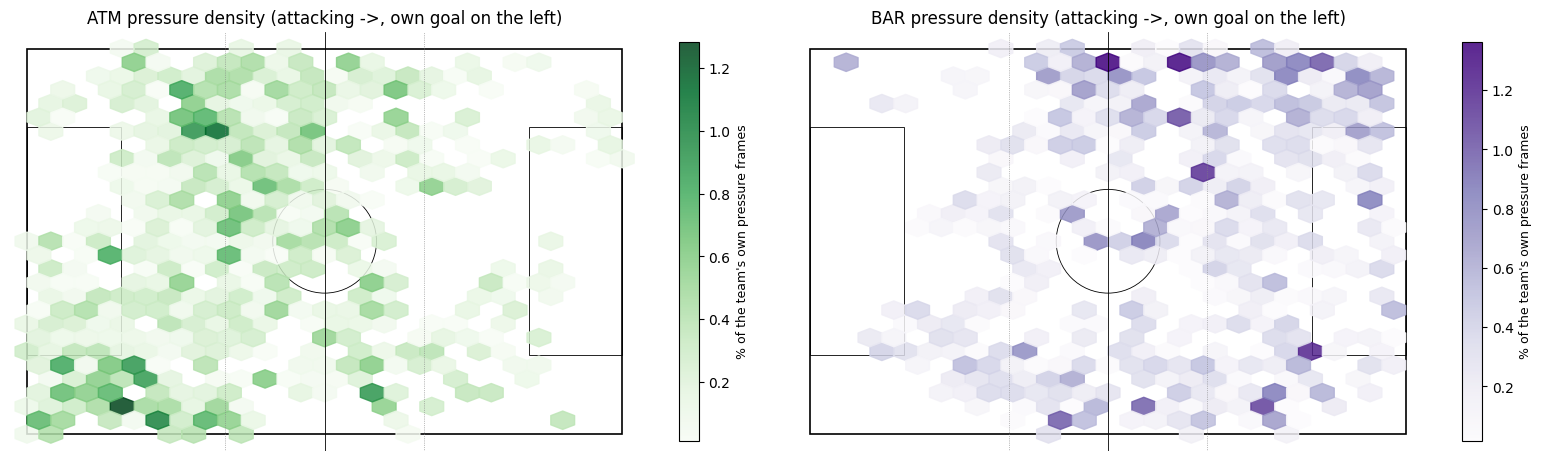

,pressure_frames,centroid_x_m,centroid_y_m,pct_in_opponent_half,pct_y_low,pct_centre,pct_y_high
team,,,,,,,
ATM,8101,38.2,32.3,24.6,39.0,27.8,33.2
BAR,6381,65.0,37.6,69.0,33.0,23.0,44.1


SUMMARY
  ATM: pressure centred 38 m from their own goal, 25% of it in the opponent half; most pressure in the y_low channel (y_low / y_high are neutral labels in the attacking frame, centre is the middle third of the width).
  BAR: pressure centred 65 m from their own goal, 69% of it in the opponent half; most pressure in the y_high channel (y_low / y_high are neutral labels in the attacking frame, centre is the middle third of the width).


In [6]:
pp = frames[frames["under_pressure"]].dropna(subset=["x", "y"]).copy()
pp["press_x"], pp["press_y"] = team_frame(pp["x"], pp["y"], pp["def_team"])
tol = PRM["BOUNDS_TOL_M"]
inb = pp["press_x"].between(-tol, PITCH_LENGTH + tol) & pp["press_y"].between(-tol, PITCH_WIDTH + tol)
print(f"dropped {int((~inb).sum())} / {len(pp)} pressure points outside the pitch (+/- {tol} m)")
pp = pp[inb]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, team, cmap in zip(axes, TEAMS[:2], ["Greens", "Purples"]):
    sub = pp[pp["def_team"] == team]
    draw_pitch(ax)
    if len(sub):
        w = np.full(len(sub), 100.0 / len(sub))
        hb = ax.hexbin(sub["press_x"], sub["press_y"], C=w, reduce_C_function=np.sum, gridsize=PRM["HEATMAP_GRIDSIZE"],
                       cmap=cmap, mincnt=1, extent=(0, PITCH_LENGTH, 0, PITCH_WIDTH), alpha=0.85)
        plt.colorbar(hb, ax=ax, shrink=0.7).set_label("% of the team's own pressure frames", fontsize=9)
    ax.set_title(f"{name(team)} pressure density (attacking ->, own goal on the left)", fontsize=12)
plt.tight_layout(); plt.show()

rows = []
for team in TEAMS:
    s = pp[pp["def_team"] == team]
    ch = pd.cut(s["press_y"], [-np.inf, PITCH_WIDTH / 3, 2 * PITCH_WIDTH / 3, np.inf], labels=["y_low", "centre", "y_high"], right=False)
    chp = ch.value_counts(normalize=True).reindex(["y_low", "centre", "y_high"]).fillna(0) * 100
    rows.append(dict(team=name(team), pressure_frames=len(s), centroid_x_m=round(s["press_x"].mean(), 1), centroid_y_m=round(s["press_y"].mean(), 1),
                     pct_in_opponent_half=round(100 * (s["press_x"] >= PITCH_LENGTH / 2).mean(), 1),
                     pct_y_low=round(chp["y_low"], 1), pct_centre=round(chp["centre"], 1), pct_y_high=round(chp["y_high"], 1)))
t4 = pd.DataFrame(rows).set_index("team")
display(t4)

print("SUMMARY")
for team in TEAMS:
    r = t4.loc[name(team)]
    side = r[["pct_y_low", "pct_centre", "pct_y_high"]].astype(float).idxmax().replace("pct_", "")
    print(f"  {name(team)}: pressure centred {r['centroid_x_m']:.0f} m from their own goal, {r['pct_in_opponent_half']:.0f}% of it in the opponent half; "
          f"most pressure in the {side} channel (y_low / y_high are neutral labels in the attacking frame, centre is the middle third of the width).")

## 5. Pressing intensity over time (5-minute bins)
% of a team's out-of-possession frames spent pressing, per 5-minute block of the match clock. A team/bin with fewer than `MIN_BIN_FRAMES` out-of-possession frames is **masked** (shown as NaN and left out of the plot), because one short sequence would swing the average.

,ATM pressing %,ATM frames,BAR pressing %,BAR frames
0-5 min,25.9,5123,51.2,1647
5-10 min,22.1,3692,31.0,1974
10-15 min,27.8,3084,21.2,2733
15-20 min,23.7,3444,46.8,1224
20-25 min,22.9,2938,25.8,1380
25-30 min,23.1,2818,21.6,2619
30-35 min,26.6,3651,19.7,2318
35-40 min,32.0,3818,34.5,2417
40-45 min,26.6,1945,32.0,3913
45-50 min,NaN,441,23.9,1287


masked team/bin cells (fewer than 500 out-of-possession frames = 20 s): 1


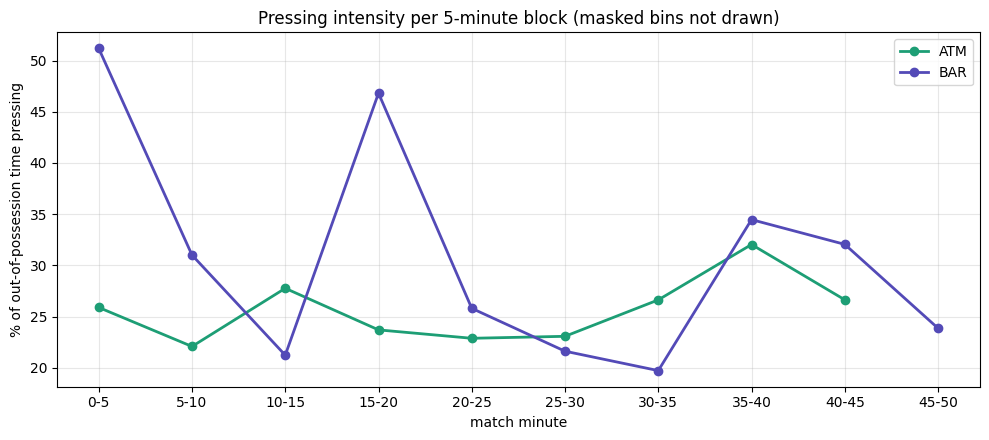

SUMMARY
  ATM: highest in 35-40 min (32.0%), lowest in 5-10 min (22.1%), 9 reliable bins out of 10.
  BAR: highest in 0-5 min (51.2%), lowest in 30-35 min (19.7%), 10 reliable bins out of 10.


In [7]:
bm, minf = PRM["BIN_MINUTES"], PRM["MIN_BIN_FRAMES"]
fr = frames.copy()
fr["bin"] = (fr["frame_idx"] / FPS // (bm * 60)).astype(int)
agg = fr.groupby(["def_team", "bin"]).agg(n_frames=("under_pressure", "size"), pct=("under_pressure", "mean")).reset_index()
agg["pct"] = 100 * agg["pct"]
agg["masked"] = agg["n_frames"] < minf
agg.loc[agg["masked"], "pct"] = np.nan
agg["bin_label"] = agg["bin"].apply(lambda b: f"{b * bm}-{(b + 1) * bm} min")

pct_tab = agg.pivot(index="bin", columns="def_team", values="pct")
n_tab = agg.pivot(index="bin", columns="def_team", values="n_frames").fillna(0).astype(int)
t5 = pd.DataFrame(index=pct_tab.index)
for team in TEAMS:
    t5[f"{name(team)} pressing %"] = pct_tab[team].round(1) if team in pct_tab else np.nan
    t5[f"{name(team)} frames"] = n_tab[team] if team in n_tab else 0
t5.index = [f"{b * bm}-{(b + 1) * bm} min" for b in t5.index]
display(t5)
print(f"masked team/bin cells (fewer than {minf} out-of-possession frames = {minf / FPS:.0f} s):", int(agg["masked"].sum()))

fig, ax = plt.subplots(figsize=(10, 4.5))
for team, col in zip(TEAMS[:2], ["#1D9E75", "#534AB7"]):
    s = agg[agg["def_team"] == team].sort_values("bin")
    ax.plot(s["bin"], s["pct"], marker="o", linewidth=2, color=col, label=name(team))
ax.set_xticks(sorted(agg["bin"].unique())); ax.set_xticklabels([f"{b * bm}-{(b + 1) * bm}" for b in sorted(agg["bin"].unique())])
ax.set_xlabel("match minute"); ax.set_ylabel("% of out-of-possession time pressing"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Pressing intensity per 5-minute block (masked bins not drawn)")
plt.tight_layout(); plt.show()

print("SUMMARY")
for team in TEAMS:
    s = agg[(agg["def_team"] == team) & ~agg["masked"]]
    if s.empty:
        print(f"  {name(team)}: no bin with enough frames."); continue
    hi_, lo_ = s.loc[s["pct"].idxmax()], s.loc[s["pct"].idxmin()]
    print(f"  {name(team)}: highest in {hi_['bin_label']} ({hi_['pct']:.1f}%), lowest in {lo_['bin_label']} ({lo_['pct']:.1f}%), "
          f"{len(s)} reliable bins out of {int((agg['def_team'] == team).sum())}.")

## 6. PPDA (passes per defensive action)
`PPDA = opponent completed passes / defensive actions` (interceptions + tackles) of the defending team, **both counted outside that team's own defensive third** (own third = the first 35 m from its own goal). Zones are always taken in the *defending* team's frame. Lower PPDA = more aggressive, higher-up pressing.
Passes and actions are rebuilt from carrier transitions in `frames`: same-team handover >= 3 m = completed pass, team change >= 3 m = interception, team change < 3 m = tackle, keeper claims excluded.

In [8]:
res = detect_passes(); passes, actions, info = res["passes"], res["actions"], res["info"]
print(f"detection: {info['carrier_runs']} carrier runs, {info['transitions']} transitions ({info['within_gap']} within {PRM['MAX_RECEPTION_GAP_SEC']} s), "
      f"{info['missing_positions']} skipped for missing positions, {info['gk_claims_excluded']} keeper claims excluded -> "
      f"{len(passes)} pass attempts, {len(actions)} defensive actions\n")

rows = []
for team in TEAMS:
    opp = 1 - team
    p = passes[(passes["outcome"] == "completed") & (passes["passer_team"] == opp)]
    p_own = team_frame(p["release_x"], p["release_y"], team)[0] < THIRD_1_M          # in the defending team's own third
    a = actions[actions["defending_team"] == team]
    a_own = team_frame(a["x"], a["y"], team)[0] < THIRD_1_M
    n_pass, n_act = int((~p_own).sum()), int((~a_own).sum())
    rows.append(dict(team=name(team), passes_allowed=n_pass, defensive_actions=n_act,
                     interceptions=int(((a["action_type"] == "interception").to_numpy() & ~a_own).sum()),
                     tackles=int(((a["action_type"] == "tackle").to_numpy() & ~a_own).sum()),
                     PPDA=round(n_pass / n_act, 2) if n_act else np.nan,
                     excluded_own_third_passes=int(p_own.sum()), excluded_own_third_actions=int(a_own.sum())))
t6 = pd.DataFrame(rows).set_index("team")
display(t6)

A, B = TEAMS[:2]
pa, pb = t6.loc[name(A), "PPDA"], t6.loc[name(B), "PPDA"]
print("\nSUMMARY")
print(f"  PPDA: {name(A)} {pa:.2f}, {name(B)} {pb:.2f} (lower = more aggressive pressing).")
if pd.notna(pa) and pd.notna(pb):
    print(f"  {name(A if pa < pb else B)} press more aggressively by this measure.")
small = [n for n in t6.index if t6.loc[n, "defensive_actions"] < 10]
if small:
    print(f"  CAUTION: fewer than 10 defensive actions for {small}; PPDA is unstable at that sample size.")

detection: 684 carrier runs, 683 transitions (497 within 2.0 s), 13 skipped for missing positions, 3 keeper claims excluded -> 437 pass attempts, 115 defensive actions



,passes_allowed,defensive_actions,interceptions,tackles,PPDA,excluded_own_third_passes,excluded_own_third_actions
team,,,,,,,
ATM,171,25,18,7,6.84,58,34
BAR,122,49,34,15,2.49,8,7



SUMMARY
  PPDA: ATM 6.84, BAR 2.49 (lower = more aggressive pressing).
  BAR press more aggressively by this measure.


## 7. Time-to-press after losing the ball
For every **turnover** (a possession spell that starts right after the opponent had the ball, `start_type == "turnover"`), the time from the start of the new spell until the team that just lost the ball is first pressing the new carrier, searched within `TTP_WINDOW_SEC` (10 s). Turnovers with no press in the window are counted but have no time, so they are not in the mean / median / min / max.

In [9]:
win, grace = F(PRM["TTP_WINDOW_SEC"]), F(PRM["TTP_GRACE_SEC"])
tv = spells.loc[spells["start_type"] == "turnover", ["spell_id", "team", "start_frame", "duration_sec"]].copy()
tv["losing_team"] = 1 - tv["team"]                          # the team that lost the ball = the team that has to press
pf_ = frames.loc[frames["under_pressure"], ["frame_idx", "spell_id"]]
m = tv.merge(pf_, on="spell_id", how="left")
m = m[(m["frame_idx"] >= m["start_frame"] + grace) & (m["frame_idx"] <= m["start_frame"] + win)]
tv["first_press_frame"] = tv["spell_id"].map(m.groupby("spell_id")["frame_idx"].min())
tv["time_to_press_sec"] = (tv["first_press_frame"] - tv["start_frame"]) / FPS
tv["pressed"] = tv["time_to_press_sec"].notna()
tv["ended_before_window"] = (~tv["pressed"]) & (tv["duration_sec"] < PRM["TTP_WINDOW_SEC"])

rows = []
for team in TEAMS:
    s = tv[tv["losing_team"] == team]; ttp = s["time_to_press_sec"].dropna()
    rows.append(dict(team_that_lost_ball=name(team), turnovers=len(s), pressed_within_window=int(s["pressed"].sum()),
                     pressed_pct=round(100 * s["pressed"].mean(), 1) if len(s) else np.nan,
                     mean_sec=round(ttp.mean(), 2) if len(ttp) else np.nan, median_sec=round(ttp.median(), 2) if len(ttp) else np.nan,
                     min_sec=round(ttp.min(), 2) if len(ttp) else np.nan, max_sec=round(ttp.max(), 2) if len(ttp) else np.nan,
                     not_pressed=int((~s["pressed"]).sum()), of_which_new_spell_shorter_than_window=int(s["ended_before_window"].sum())))
t7 = pd.DataFrame(rows).set_index("team_that_lost_ball")
display(t7)
print(f"window = {PRM['TTP_WINDOW_SEC']:.0f} s, grace = {PRM['TTP_GRACE_SEC']:.1f} s, {len(tv)} turnovers in total")

print("\nSUMMARY")
for team in TEAMS:
    r = t7.loc[name(team)]
    if r["pressed_within_window"] == 0:
        print(f"  {name(team)}: no press detected within {PRM['TTP_WINDOW_SEC']:.0f} s after any of their {int(r['turnovers'])} turnovers."); continue
    print(f"  {name(team)}: after losing the ball {int(r['turnovers'])} times they pressed within {PRM['TTP_WINDOW_SEC']:.0f} s on {int(r['pressed_within_window'])} "
          f"({r['pressed_pct']:.0f}%), median {r['median_sec']:.2f} s (mean {r['mean_sec']:.2f}, min {r['min_sec']:.2f}, max {r['max_sec']:.2f}).")
if PRM["TTP_GRACE_SEC"] == 0:
    print("  NOTE: with TTP_GRACE_SEC = 0 the shortest times can just be the turnover contest itself (the player who lost the ball is still beside the new carrier). "
          "Set TTP_GRACE_SEC = 1.0 to ignore the first second.")

,turnovers,pressed_within_window,pressed_pct,mean_sec,median_sec,min_sec,max_sec,not_pressed,of_which_new_spell_shorter_than_window
team_that_lost_ball,,,,,,,,,
ATM,57,44,77.2,1.45,0.58,0.0,9.56,13,5
BAR,58,50,86.2,1.37,0.48,0.0,9.76,8,6


window = 10 s, grace = 0.0 s, 115 turnovers in total

SUMMARY
  ATM: after losing the ball 57 times they pressed within 10 s on 44 (77%), median 0.58 s (mean 1.45, min 0.00, max 9.56).
  BAR: after losing the ball 58 times they pressed within 10 s on 50 (86%), median 0.48 s (mean 1.37, min 0.00, max 9.76).
  NOTE: with TTP_GRACE_SEC = 0 the shortest times can just be the turnover contest itself (the player who lost the ball is still beside the new carrier). Set TTP_GRACE_SEC = 1.0 to ignore the first second.


## 8. Pass success rate, under pressure vs not
A pass attempt (completed or intercepted; tackles and keeper claims are not passes) counts as **under pressure** if the opponent was pressing (sustained `under_pressure`) at any frame in the `PRESSURE_LOOKBACK_SEC` (1 s) up to the release. Success = completed. 95% Wilson intervals are shown because the counts are small.

**What this measures:** completion among *resolved* passes only. A pass counts as failed only when an opponent takes the ball at 3 m or more from the passer. Duel losses (dispossessed within 3 m) and balls out of play (gap over 2 s) are not in this table, and both are more common under pressure, so a higher rate under pressure does not mean pressure helps. See 8b for the check.

In [10]:
res = detect_passes(); passes = res["passes"].copy()
L = F(PRM["PRESSURE_LOOKBACK_SEC"])
n_f = int(frames["frame_idx"].max()) + 2

def pressed_at(team, release_frames):
    """True if the opponent of `team` was pressing `team` at any frame in [release - L, release]."""
    flag = np.zeros(n_f + 1, dtype=np.int64)
    idx = frames.loc[frames["under_pressure"] & (frames["poss_team"] == team), "frame_idx"].to_numpy()
    flag[idx + 1] = 1
    cs = np.cumsum(flag)                                   # cs[k] = pressing frames with frame_idx < k
    rel = np.asarray(release_frames, dtype=int)
    return (cs[rel + 1] - cs[np.maximum(rel - L, 0)]) > 0

passes["under_pressure"] = False
for team in TEAMS:
    mk = (passes["passer_team"] == team).to_numpy()
    passes.loc[mk, "under_pressure"] = pressed_at(team, passes.loc[mk, "release_frame"])
passes["success"] = passes["outcome"] == "completed"

rows = []
for team in TEAMS:
    for state, label in [(True, "under pressure"), (False, "not under pressure")]:
        s = passes[(passes["passer_team"] == team) & (passes["under_pressure"] == state)]
        n, k = len(s), int(s["success"].sum()); lo, hi = wilson(k, n)
        rows.append(dict(team=name(team), state=label, passes=n, completed=k, intercepted=n - k,
                         success_rate_pct=round(100 * k / n, 1) if n else np.nan,
                         ci95=f"{100 * lo:.0f}-{100 * hi:.0f}" if n else "n/a"))
t8 = pd.DataFrame(rows).set_index(["team", "state"])
display(t8)

print("\nSUMMARY")
for team in TEAMS:
    u, nu = t8.loc[(name(team), "under pressure")], t8.loc[(name(team), "not under pressure")]
    share = 100 * u["passes"] / max(1, u["passes"] + nu["passes"])
    if u["passes"] and nu["passes"]:
        d = u["success_rate_pct"] - nu["success_rate_pct"]
        print(f"  {name(team)}: {u['success_rate_pct']:.1f}% of passes completed under pressure ({int(u['passes'])} passes) vs {nu['success_rate_pct']:.1f}% "
              f"without ({int(nu['passes'])}), a gap of {d:+.1f} points; {share:.0f}% of their passes were under pressure.")
    else:
        print(f"  {name(team)}: not enough passes in one of the two states to compare.")
print("  Wide intervals mean the difference between the two states may not be reliable. Duel losses and out-of-play balls are NOT counted as failures here (see 8b).")

passes  completed  intercepted  success_rate_pct   ci95
team state                                                                      
ATM  under pressure         105         86           19              81.9  73-88
     not under pressure      63         44           19              69.8  58-80
BAR  under pressure         138        120           18              87.0  80-92
     not under pressure     131        109           22              83.2  76-89


SUMMARY
  ATM: 81.9% of passes completed under pressure (105 passes) vs 69.8% without (63), a gap of +12.1 points; 62% of their passes were under pressure.
  BAR: 87.0% of passes completed under pressure (138 passes) vs 83.2% without (131), a gap of +3.8 points; 51% of their passes were under pressure.
  Wide intervals mean the difference between the two states may not be reliable. Duel losses and out-of-play balls are NOT counted as failures here (see 8b).


## 8b. Check on section 8: what the pressed / unpressed passes look like, and retention with duel losses counted
Section 8 can show a *higher* completion rate under pressure because (a) duel losses are not counted as failed passes and (b) pressed carriers play shorter, safer passes. This cell prints both effects:
1. pass length and direction by pressure state;
2. **retention** = completed passes / (all pass attempts + duel losses), where a duel loss is a carrier dispossessed within 3 m of the next carrier.

In [11]:
res = detect_passes(); passes = res["passes"].copy(); actions = res["actions"]; info = res["info"]
L = F(PRM["PRESSURE_LOOKBACK_SEC"]); n_f = int(frames["frame_idx"].max()) + 2

def pressed_at(team, release_frames):
    flag = np.zeros(n_f + 1, dtype=np.int64)
    idx = frames.loc[frames["under_pressure"] & (frames["poss_team"] == team), "frame_idx"].to_numpy()
    flag[idx + 1] = 1
    cs = np.cumsum(flag)
    rel = np.asarray(release_frames, dtype=int)
    return (cs[rel + 1] - cs[np.maximum(rel - L, 0)]) > 0

def add_pressure(df, team_col, frame_col):
    df = df.copy(); df["under_pressure"] = False
    for team in TEAMS:
        mk = (df[team_col] == team).to_numpy()
        if mk.any():
            df.loc[mk, "under_pressure"] = pressed_at(team, df.loc[mk, frame_col])
    return df

passes = add_pressure(passes, "passer_team", "release_frame")
passes["success"] = passes["outcome"] == "completed"
duels = add_pressure(actions[actions["action_type"] == "tackle"], "attacking_team", "frame")     # carrier lost the ball in a duel

# 1) pass length and direction (progression in the passer's own attacking frame)
xr = team_frame(passes["release_x"], passes["release_y"], passes["passer_team"])[0]
xc = team_frame(passes["receive_x"], passes["receive_y"], passes["passer_team"])[0]
passes["progression_m"] = xc - xr
rows = []
for team in TEAMS:
    for state, label in [(True, "under pressure"), (False, "not under pressure")]:
        s = passes[(passes["passer_team"] == team) & (passes["under_pressure"] == state)]
        rows.append(dict(team=name(team), state=label, passes=len(s),
                         median_length_m=round(s["dist_m"].median(), 1), mean_length_m=round(s["dist_m"].mean(), 1),
                         pct_forward_3m=round(100 * (s["progression_m"] >= 3).mean(), 1) if len(s) else np.nan,
                         pct_backward_3m=round(100 * (s["progression_m"] <= -3).mean(), 1) if len(s) else np.nan,
                         pct_intercepted=round(100 * (~s["success"]).mean(), 1) if len(s) else np.nan))
print("1) what the passes look like:")
display(pd.DataFrame(rows).set_index(["team", "state"]))

# 2) retention with duel losses counted as failures
rows = []
for team in TEAMS:
    for state, label in [(True, "under pressure"), (False, "not under pressure")]:
        s = passes[(passes["passer_team"] == team) & (passes["under_pressure"] == state)]
        d = duels[(duels["attacking_team"] == team) & (duels["under_pressure"] == state)]
        n, k = len(s) + len(d), int(s["success"].sum()); lo, hi = wilson(k, n)
        rows.append(dict(team=name(team), state=label, passes=len(s), completed=k, intercepted=int((~s["success"]).sum()), lost_in_duel=len(d),
                         pass_completion_pct=round(100 * k / len(s), 1) if len(s) else np.nan,
                         retention_pct=round(100 * k / n, 1) if n else np.nan, ci95=f"{100 * lo:.0f}-{100 * hi:.0f}" if n else "n/a"))
t8b = pd.DataFrame(rows).set_index(["team", "state"])
print("\n2) retention = completed / (passes + duel losses):")
display(t8b)
print(f"balls with a gap over {PRM['MAX_RECEPTION_GAP_SEC']:.0f} s (out of play / long loose ball), not counted in either table: {info['transitions'] - info['within_gap']}")

print("\nSUMMARY")
for team in TEAMS:
    u, nu = t8b.loc[(name(team), "under pressure")], t8b.loc[(name(team), "not under pressure")]
    print(f"  {name(team)}: pass completion {u['pass_completion_pct']:.1f}% pressed vs {nu['pass_completion_pct']:.1f}% unpressed; "
          f"with {int(u['lost_in_duel'])} pressed and {int(nu['lost_in_duel'])} unpressed duel losses counted, retention is {u['retention_pct']:.1f}% vs {nu['retention_pct']:.1f}%.")
print("  If the pressed rate stays above the unpressed one, look at table 1: shorter, more backward passes under pressure explain it.")

1) what the passes look like:


passes  median_length_m  mean_length_m  pct_forward_3m  pct_backward_3m  pct_intercepted
team state                                                                                                       
ATM  under pressure         105             12.5           13.5            35.2             34.3             18.1
     not under pressure      63             10.8           13.1            49.2             28.6             30.2
BAR  under pressure         138             13.8           15.1            37.0             38.4             13.0
     not under pressure     131             15.1           16.1            55.7             20.6             16.8


2) retention = completed / (passes + duel losses):


passes  completed  intercepted  lost_in_duel  pass_completion_pct  retention_pct   ci95
team state                                                                                                      
ATM  under pressure         105         86           19            12                 81.9           73.5  65-81
     not under pressure      63         44           19             6                 69.8           63.8  52-74
BAR  under pressure         138        120           18            15                 87.0           78.4  71-84
     not under pressure     131        109           22             4                 83.2           80.7  73-87

balls with a gap over 2 s (out of play / long loose ball), not counted in either table: 186

SUMMARY
  ATM: pass completion 81.9% pressed vs 69.8% unpressed; with 12 pressed and 6 unpressed duel losses counted, retention is 73.5% vs 63.8%.
  BAR: pass completion 87.0% pressed vs 83.2% unpressed; with 15 pressed and 4 unpressed duel losses counted, retention is 78.4% vs 80.7%.
  If the pressed rate stays above the unpressed one, look at table 1: shorter, more backward passes under pressure explain it.


## 9. Defensive line height (last-1 and last-3 defenders)
Distance from own goal of the **last outfield defender** and of the **mean of the last three**, per frame, out-of-possession frames only. Outliers (tracking glitches) are removed per team with the 1.5 x IQR rule before the mean / median / std are computed.

In [12]:
lf = line_frames()
rows = []
for col, label in [("last1", "last-1 defender"), ("last3", "last-3 defenders (mean)")]:
    base = lf.dropna(subset=[col])
    clean = iqr_clean(base, col)
    for team in TEAMS:
        b, c = base[base["team"] == team][col], clean[clean["team"] == team][col]
        rows.append(dict(team=name(team), line=label, mean_m=round(c.mean(), 1), median_m=round(c.median(), 1), std_m=round(c.std(), 1),
                         frames_kept=len(c), outliers_removed=len(b) - len(c)))
t9 = pd.DataFrame(rows).set_index(["line", "team"])
display(t9)

print("\nSUMMARY")
A, B = TEAMS[:2]
for line in ["last-1 defender", "last-3 defenders (mean)"]:
    a, b = t9.loc[(line, name(A))], t9.loc[(line, name(B))]
    print(f"  {line}: {name(A)} {a['mean_m']:.1f} m (median {a['median_m']:.1f}, std {a['std_m']:.1f}) vs {name(B)} {b['mean_m']:.1f} m "
          f"(median {b['median_m']:.1f}, std {b['std_m']:.1f}); {name(A if a['mean_m'] > b['mean_m'] else B)} defend higher.")
print("  A larger std means the line moves up and down the pitch more.")

mean_m  median_m  std_m  frames_kept  outliers_removed
line                    team                                                        
last-1 defender         ATM     26.2      23.5   13.7        30894                54
                        BAR     44.8      48.2   13.1        20283              1220
last-3 defenders (mean) ATM     27.4      24.4   13.9        30866                68
                        BAR     46.4      49.0   14.6        20068               736


SUMMARY
  last-1 defender: ATM 26.2 m (median 23.5, std 13.7) vs BAR 44.8 m (median 48.2, std 13.1); BAR defend higher.
  last-3 defenders (mean): ATM 27.4 m (median 24.4, std 13.9) vs BAR 46.4 m (median 49.0, std 14.6); BAR defend higher.
  A larger std means the line moves up and down the pitch more.


## 10. Team compactness while out of possession
Per frame, out-of-possession outfield block of the defending team:
- **depth** = mean distance from own goal of the front 3 outfield players minus that of the back 3 (needs at least 6 tracked outfield players)
- **width** = lateral spread (max y - min y) after removing outliers with the 1.5 x IQR rule
- **area** = depth x width (m²). Smaller = more compact block.

In [13]:
sh = team_shape()
rows = []
for team in TEAMS:
    s = sh[sh["team"] == team]
    row = dict(team=name(team), frames=len(s))
    for col, lab in [("depth_m", "depth"), ("width_m", "width"), ("area_m2", "area")]:
        row.update({f"{lab}_mean": round(s[col].mean(), 1), f"{lab}_median": round(s[col].median(), 1), f"{lab}_std": round(s[col].std(), 1)})
    rows.append(row)
t10 = pd.DataFrame(rows).set_index("team")
display(t10)

A, B = TEAMS[:2]
aa, ab = t10.loc[name(A), "area_mean"], t10.loc[name(B), "area_mean"]
tight, loose = (A, B) if aa <= ab else (B, A)
print("\nSUMMARY")
for team in TEAMS:
    r = t10.loc[name(team)]
    print(f"  {name(team)}: block {r['depth_mean']:.1f} m deep and {r['width_mean']:.1f} m wide on average -> {r['area_mean']:.0f} m² (median {r['area_median']:.0f}).")
print(f"  {name(tight)} defend in the more compact block, about {100 * abs(aa - ab) / max(aa, ab):.0f}% smaller by area than {name(loose)}.")

,frames,depth_mean,depth_median,depth_std,width_mean,width_median,width_std,area_mean,area_median,area_std
team,,,,,,,,,,
ATM,30713,19.2,17.9,6.7,35.8,36.6,7.8,704.0,639.7,324.1
BAR,20684,22.5,23.0,8.0,35.9,37.6,8.9,840.4,835.1,373.4



SUMMARY
  ATM: block 19.2 m deep and 35.8 m wide on average -> 704 m² (median 640).
  BAR: block 22.5 m deep and 35.9 m wide on average -> 840 m² (median 835).
  ATM defend in the more compact block, about 16% smaller by area than BAR.


## 11. Compactness while actively pressing vs not
Same shape metrics as section 10, split by whether the team is pressing the ball carrier in that frame (`under_pressure` = True) or sitting in its resting out-of-possession shape (False). This shows how the block changes when it presses; it does not by itself show that pressing causes the change.

In [14]:
sh = team_shape().dropna(subset=["under_pressure"]).copy()
sh["state"] = np.where(sh["under_pressure"].astype(bool), "pressing", "not pressing")
rows = []
for team in TEAMS:
    for state in ["pressing", "not pressing"]:
        s = sh[(sh["team"] == team) & (sh["state"] == state)]
        rows.append(dict(team=name(team), state=state, frames=len(s),
                         depth_mean=round(s["depth_m"].mean(), 1), width_mean=round(s["width_m"].mean(), 1),
                         area_mean=round(s["area_m2"].mean(), 1), area_median=round(s["area_m2"].median(), 1), area_std=round(s["area_m2"].std(), 1)))
t11 = pd.DataFrame(rows).set_index(["team", "state"])
display(t11)

print("\nSUMMARY")
for team in TEAMS:
    p, n = t11.loc[(name(team), "pressing")], t11.loc[(name(team), "not pressing")]
    if p["frames"] == 0 or n["frames"] == 0:
        print(f"  {name(team)}: not enough frames in one of the two states."); continue
    d = p["area_mean"] - n["area_mean"]
    word = "tighter" if d < 0 else "looser"
    print(f"  {name(team)}: {p['area_mean']:.0f} m² while pressing vs {n['area_mean']:.0f} m² when not -> the block is {abs(d):.0f} m² ({100 * abs(d) / n['area_mean']:.0f}%) {word} while pressing "
          f"(depth {p['depth_mean']:.1f} vs {n['depth_mean']:.1f} m, width {p['width_mean']:.1f} vs {n['width_mean']:.1f} m).")

frames  depth_mean  width_mean  area_mean  area_median  area_std
team state                                                                         
ATM  pressing        8090        19.1        35.5      692.4        616.3     321.3
     not pressing   22623        19.2        35.9      708.2        648.0     325.0
BAR  pressing        6354        22.8        37.0      854.6        842.8     330.1
     not pressing   14330        22.4        35.4      834.1        832.4     390.9


SUMMARY
  ATM: 692 m² while pressing vs 708 m² when not -> the block is 16 m² (2%) tighter while pressing (depth 19.1 vs 19.2 m, width 35.5 vs 35.9 m).
  BAR: 855 m² while pressing vs 834 m² when not -> the block is 20 m² (2%) looser while pressing (depth 22.8 vs 22.4 m, width 37.0 vs 35.4 m).


## 12. Third x channel grid
Where each team's pressure happens: the 9 cells formed by the three thirds (own / middle / attacking, in the pressing team's attacking direction) and three lateral channels (thirds of the pitch width). Each cell is the % of the team's pressure frames. `left` / `right` follow `LEFT_IS_LOW_Y_ATT` from your build-up notebook (looking towards the opponent's goal); flip that switch in the setup cell if they look mirrored on the video.

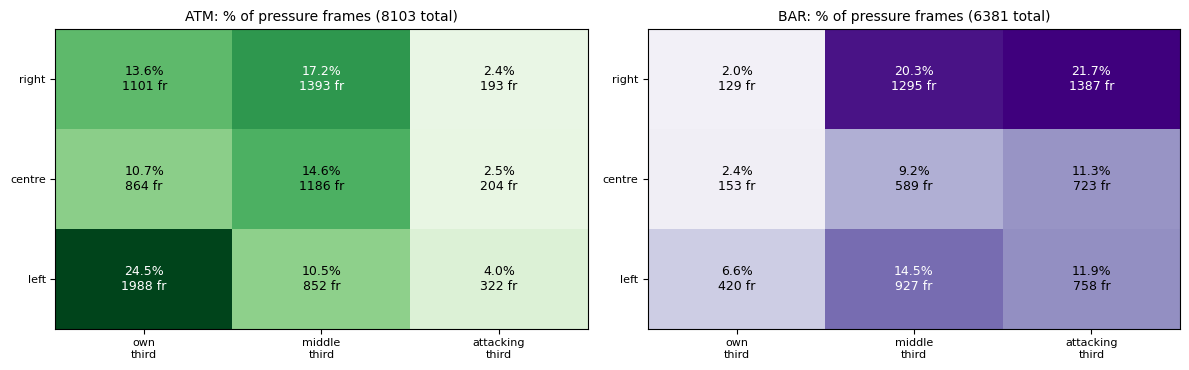

third         own_third  middle_third  attacking_third
team channel                                          
ATM  left          24.5          10.5              4.0
     centre        10.7          14.6              2.5
     right         13.6          17.2              2.4
BAR  left           6.6          14.5             11.9
     centre         2.4           9.2             11.3
     right          2.0          20.3             21.7

SUMMARY
  ATM: biggest cell = left channel of the own third (24.5% of their pressure). By third own/middle/attacking: 49/42/9%. By channel left/centre/right: 39/28/33%.
  BAR: biggest cell = right channel of the attacking third (21.7% of their pressure). By third own/middle/attacking: 11/44/45%. By channel left/centre/right: 33/23/44%.


In [15]:
fz = frames_zoned()
pr_ = fz[fz["under_pressure"]].dropna(subset=["zone", "channel"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
rows = []
for ax, team, cmap in zip(axes, TEAMS[:2], ["Greens", "Purples"]):
    s = pr_[pr_["def_team"] == team]
    cnt = s.groupby(["channel", "zone"]).size().unstack(fill_value=0).reindex(index=CH_ORDER, columns=ZONES, fill_value=0)
    tot = int(cnt.values.sum())
    pct = 100 * cnt / tot if tot else cnt * np.nan
    draw_grid(ax, pct.to_numpy(), [[f"{pct.iloc[i, j]:.1f}%\n{cnt.iloc[i, j]} fr" for j in range(3)] for i in range(3)],
              f"{name(team)}: % of pressure frames ({tot} total)", cmap=cmap)
    for ch in CH_ORDER:
        for z in ZONES:
            rows.append(dict(team=name(team), third=z, channel=CH_LABEL[ch], frames=int(cnt.loc[ch, z]), seconds=round(cnt.loc[ch, z] / FPS, 1),
                             pct_of_team_pressure=round(pct.loc[ch, z], 1)))
plt.tight_layout(); plt.show()
t12 = pd.DataFrame(rows)
display(t12.pivot_table(index=["team", "channel"], columns="third", values="pct_of_team_pressure", sort=False)[ZONES])

print("SUMMARY")
for team in TEAMS:
    s = t12[t12["team"] == name(team)]
    top = s.loc[s["pct_of_team_pressure"].idxmax()]
    by_third = s.groupby("third")["pct_of_team_pressure"].sum().reindex(ZONES)
    by_ch = s.groupby("channel")["pct_of_team_pressure"].sum()
    print(f"  {name(team)}: biggest cell = {top['channel']} channel of the {top['third'].replace('_', ' ')} ({top['pct_of_team_pressure']:.1f}% of their pressure). "
          f"By third own/middle/attacking: {by_third.iloc[0]:.0f}/{by_third.iloc[1]:.0f}/{by_third.iloc[2]:.0f}%. "
          f"By channel left/centre/right: {by_ch['left']:.0f}/{by_ch['centre']:.0f}/{by_ch['right']:.0f}%.")

## 13. Zone intensity per time in zone
Section 3 and 12 count pressure frames, but a team that spends more time defending in a zone naturally has more pressure there. This normalises by the time the ball is in the zone while the team is out of possession:
`zone intensity % = pressing frames with the ball in the zone / out-of-possession frames with the ball in the zone`. Cells with fewer than `MIN_CELL_FRAMES` ball-in-cell frames are greyed out.

ball_in_zone_sec  pct_of_out_of_possession_time  pressing_sec  zone_intensity_pct
team third                                                                                             
ATM  own_third                   412.8                           33.3         158.1                38.3
     middle_third                584.7                           47.2         137.2                23.5
     attacking_third             240.7                           19.4          28.8                11.9
BAR  own_third                   130.6                           15.2          28.1                21.5
     middle_third                313.5                           36.4         112.4                35.9
     attacking_third             416.4                           48.4         114.7                27.6

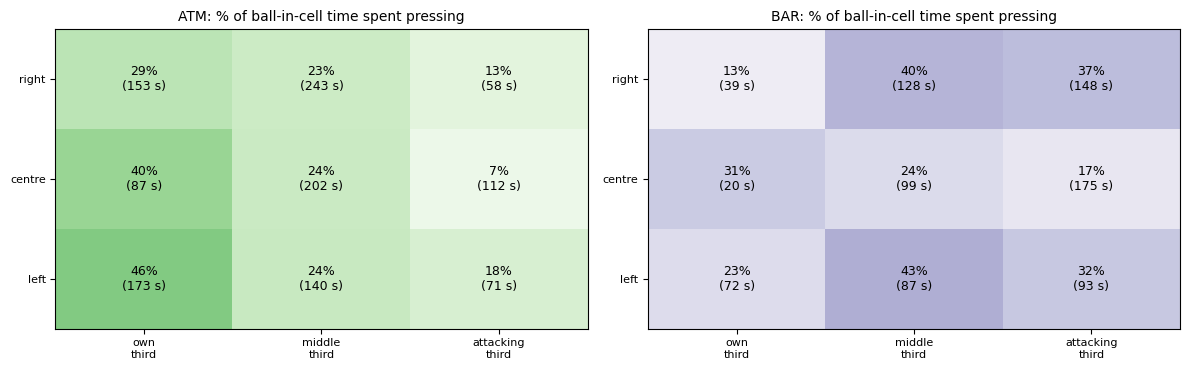

SUMMARY
  ATM: presses most when the ball is in the own third (38% of that time) and least in the attacking third (12%). Time with the ball in each third (own/middle/attacking): 33%/47%/19% of their out-of-possession time.
  BAR: presses most when the ball is in the middle third (36% of that time) and least in the own third (22%). Time with the ball in each third (own/middle/attacking): 15%/36%/48% of their out-of-possession time.


In [16]:
fz = frames_zoned().dropna(subset=["zone", "channel"])
minf = PRM["MIN_CELL_FRAMES"]

# ---- by third
g = fz.groupby(["def_team", "zone"]).agg(ball_frames=("under_pressure", "size"), pressing_frames=("under_pressure", "sum")).reset_index()
rows = []
for team in TEAMS:
    tot_ball = int(g.loc[g["def_team"] == team, "ball_frames"].sum())
    for z in ZONES:
        r = g[(g["def_team"] == team) & (g["zone"] == z)]
        nb_, npf = (int(r["ball_frames"].iloc[0]), int(r["pressing_frames"].iloc[0])) if len(r) else (0, 0)
        rows.append(dict(team=name(team), third=z, ball_in_zone_sec=round(nb_ / FPS, 1), pct_of_out_of_possession_time=round(100 * nb_ / tot_ball, 1) if tot_ball else np.nan,
                         pressing_sec=round(npf / FPS, 1), zone_intensity_pct=round(100 * npf / nb_, 1) if nb_ >= minf else np.nan))
t13 = pd.DataFrame(rows).set_index(["team", "third"])
display(t13)

# ---- by third x channel
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, team, cmap in zip(axes, TEAMS[:2], ["Greens", "Purples"]):
    s = fz[fz["def_team"] == team]
    n = s.groupby(["channel", "zone"]).size().unstack(fill_value=0).reindex(index=CH_ORDER, columns=ZONES, fill_value=0)
    p = s[s["under_pressure"]].groupby(["channel", "zone"]).size().unstack(fill_value=0).reindex(index=CH_ORDER, columns=ZONES, fill_value=0)
    inten = (100 * p / n.replace(0, np.nan)).where(n >= minf)
    draw_grid(ax, inten.to_numpy(), [["n/a" if pd.isna(inten.iloc[i, j]) else f"{inten.iloc[i, j]:.0f}%\n({n.iloc[i, j] / FPS:.0f} s)" for j in range(3)] for i in range(3)],
              f"{name(team)}: % of ball-in-cell time spent pressing", cmap=cmap, vmax=100)
plt.tight_layout(); plt.show()

print("SUMMARY")
for team in TEAMS:
    r = t13.loc[name(team)].dropna(subset=["zone_intensity_pct"])
    if r.empty:
        print(f"  {name(team)}: not enough frames."); continue
    hi, lo = r["zone_intensity_pct"].idxmax(), r["zone_intensity_pct"].idxmin()
    print(f"  {name(team)}: presses most when the ball is in the {hi.replace('_', ' ')} ({r.loc[hi, 'zone_intensity_pct']:.0f}% of that time) and least in the {lo.replace('_', ' ')} "
          f"({r.loc[lo, 'zone_intensity_pct']:.0f}%). Time with the ball in each third (own/middle/attacking): "
          + "/".join(f"{t13.loc[(name(team), z), 'pct_of_out_of_possession_time']:.0f}%" for z in ZONES) + " of their out-of-possession time.")

## 14. Press-to-regain rate
A **pressing episode** = a run of pressing frames (`under_pressure`) inside one possession spell, gaps of up to `EPISODE_GAP_FRAMES` bridged, lasting at least `MIN_EPISODE_SEC`. It counts as a **regain** if the pressing team becomes the ball carrier within `REGAIN_WINDOW_SEC` (5 s) after the episode ends. `regained and held` is stricter: the pressing team also starts a stable possession spell (holds the ball 1.5 s or more) in that window.

In [17]:
W, GAP, MIN_F = F(PRM["REGAIN_WINDOW_SEC"]), PRM["EPISODE_GAP_FRAMES"], F(PRM["MIN_EPISODE_SEC"])
fz = frames_zoned().sort_values("frame_idx")

# carrier-team lookup: cs[T][k] = number of frames before k in which team T has the ball carrier
team_of = roster.drop_duplicates("track_id").set_index("track_id")["team"].to_dict()
car = frames.dropna(subset=["carrier_track_id"])[["frame_idx", "carrier_track_id"]].copy()
car["team"] = car["carrier_track_id"].astype(int).map(team_of)
car = car.dropna(subset=["team"])
n_f = int(frames["frame_idx"].max()) + W + 3
cs = {}
for T in TEAMS:
    a = np.zeros(n_f + 1, dtype=np.int64)
    a[car.loc[car["team"] == T, "frame_idx"].to_numpy(dtype=int) + 1] = 1
    cs[T] = np.cumsum(a)

def true_runs(mask, fidx, spell):
    brk = np.r_[True, (np.diff(fidx) != 1) | (spell[1:] != spell[:-1]) | (mask[1:] != mask[:-1])]
    st = np.flatnonzero(brk); en = np.r_[st[1:] - 1, len(mask) - 1]
    return [(int(s_), int(e_)) for s_, e_ in zip(st, en) if mask[s_]]

eps = []
for T in TEAMS:
    s = fz[fz["def_team"] == T]
    f_, up, sp = s["frame_idx"].to_numpy(), s["under_pressure"].to_numpy(bool), s["spell_id"].to_numpy()
    npr, zone = s["n_pressing"].to_numpy(), s["zone"].to_numpy()
    merged = []
    for a, b in true_runs(up, f_, sp):
        if merged and sp[a] == sp[merged[-1][1]] and f_[a] - f_[merged[-1][1]] - 1 <= GAP:
            merged[-1][1] = b                                        # bridge a short gap inside the same spell
        else:
            merged.append([a, b])
    starts_T = np.sort(spells.loc[spells["team"] == T, "start_frame"].to_numpy())
    for a, b in merged:
        n = int(f_[b] - f_[a] + 1)
        if n < MIN_F:
            continue
        end = int(f_[b])
        eps.append(dict(team=T, spell_id=int(sp[a]), start_frame=int(f_[a]), end_frame=end, n_frames=n, max_pressers=int(npr[a:b + 1].max()), start_zone=zone[a],
                        regained=bool(cs[T][end + W + 1] - cs[T][end + 1] > 0),
                        regained_and_held=bool(np.searchsorted(starts_T, end + W, side="right") - np.searchsorted(starts_T, end, side="right") > 0)))
eps = pd.DataFrame(eps)
assert len(eps), "no pressing episodes found"

def regain_table(df, by):
    rows = []
    for team in TEAMS:
        for key, s in df[df["team"] == team].groupby(by, observed=True):
            rows.append({"team": name(team), by: key, "episodes": len(s), "regained": int(s["regained"].sum()), "regain_pct": round(100 * s["regained"].mean(), 1),
                         "regained_and_held": int(s["regained_and_held"].sum()), "regain_and_held_pct": round(100 * s["regained_and_held"].mean(), 1)})
    return pd.DataFrame(rows).set_index(["team", by])

eps["all"] = "all episodes"
eps["pressers"] = np.where(eps["max_pressers"] >= 2, "2+ pressers", "1 presser")
eps["start_third"] = pd.Categorical(eps["start_zone"], categories=ZONES, ordered=True)
print(f"{len(eps)} pressing episodes (>= {PRM['MIN_EPISODE_SEC']} s, gaps <= {GAP} frames bridged); regain window {PRM['REGAIN_WINDOW_SEC']:.0f} s\n")
print("overall:"); t14 = regain_table(eps, "all"); display(t14)
print("by number of pressers (max at the same time in the episode):"); display(regain_table(eps, "pressers"))
print("by third where the episode started (pressing team's attacking frame):"); display(regain_table(eps, "start_third"))
print("episode length (s):"); display(eps.assign(sec=eps["n_frames"] / FPS).groupby(eps["team"].map(name))["sec"].describe().round(1)[["count", "mean", "50%", "max"]])

print("SUMMARY")
for team in TEAMS:
    r = t14.loc[(name(team), "all episodes")]
    print(f"  {name(team)}: {int(r['episodes'])} pressing episodes, ball back within {PRM['REGAIN_WINDOW_SEC']:.0f} s after {int(r['regained'])} ({r['regain_pct']:.1f}%); "
          f"{int(r['regained_and_held'])} ({r['regain_and_held_pct']:.1f}%) were regained and held.")
print("  There is no baseline here: a regain rate says how often a press is followed by the ball, not how much of that the press caused.")
if (t14["episodes"] < 15).any():
    print("  CAUTION: fewer than 15 episodes for a team, the percentages are unstable.")

416 pressing episodes (>= 0.5 s, gaps <= 5 frames bridged); regain window 5 s

overall:


,,episodes,regained,regain_pct,regained_and_held,regain_and_held_pct
team,all,,,,,
ATM,all episodes,236,82,34.7,76,32.2
BAR,all episodes,180,69,38.3,63,35.0


by number of pressers (max at the same time in the episode):


episodes  regained  regain_pct  regained_and_held  regain_and_held_pct
team pressers                                                                           
ATM  1 presser         175        53        30.3                 49                 28.0
     2+ pressers        61        29        47.5                 27                 44.3
BAR  1 presser         133        44        33.1                 41                 30.8
     2+ pressers        47        25        53.2                 22                 46.8

by third where the episode started (pressing team's attacking frame):


episodes  regained  regain_pct  regained_and_held  regain_and_held_pct
team start_third                                                                            
ATM  own_third             104        53        51.0                 49                 47.1
     middle_third          103        23        22.3                 21                 20.4
     attacking_third        29         6        20.7                  6                 20.7
BAR  own_third              22         9        40.9                  8                 36.4
     middle_third           74        32        43.2                 31                 41.9
     attacking_third        84        28        33.3                 24                 28.6

episode length (s):


,count,mean,50%,max
team,,,,
ATM,236.0,1.3,1.0,7.4
BAR,180.0,1.4,1.1,5.6


SUMMARY
  ATM: 236 pressing episodes, ball back within 5 s after 82 (34.7%); 76 (32.2%) were regained and held.
  BAR: 180 pressing episodes, ball back within 5 s after 69 (38.3%); 63 (35.0%) were regained and held.
  There is no baseline here: a regain rate says how often a press is followed by the ball, not how much of that the press caused.


## 15. Pressing time per player and share of the team's pressing
A defender counts as pressing in a frame when his own press flag is on (within 5 m of the ball carrier and within 2 m or closing at 1.5 m/s or more) **and** the team is in a sustained pressing phase (`under_pressure`), so one-frame flickers are ignored. Per player:
- `share_of_team_presser_time_pct`: his pressing frames / all pressing frames of all his team's players (sums to 100%; several players press at once)
- `involved_in_pct_of_team_pressing`: the % of the team's pressing frames in which he was one of the pressers
- `pressing_rate_pct`: his pressing frames / the frames he was tracked while his team defended (fair to players with less time on the pitch)

In [18]:
d = player_press_frames()
g = d.groupby(["team", "player"]).agg(number=("number", "first"), defending_frames=("pressing", "size"), pressing_frames=("pressing", "sum"))
g["pressing_frames"] = g["pressing_frames"].astype(int)
team_press_frames = frames[frames["under_pressure"]].groupby("def_team").size()
team_presser_total = g.groupby(level="team")["pressing_frames"].transform("sum")
team_idx = g.index.get_level_values("team")
t15 = pd.DataFrame({"number": g["number"], "defending_sec": (g["defending_frames"] / FPS).round(0), "pressing_sec": (g["pressing_frames"] / FPS).round(1),
                    "share_of_team_presser_time_pct": (100 * g["pressing_frames"] / team_presser_total).round(1),
                    "involved_in_pct_of_team_pressing": (100 * g["pressing_frames"] / team_press_frames.reindex(team_idx).to_numpy()).round(1),
                    "pressing_rate_pct": (100 * g["pressing_frames"] / g["defending_frames"]).round(1)})
for team in TEAMS:
    print(f"\n{name(team)}  (team pressing time {team_press_frames.get(team, 0) / FPS:.0f} s; players listed by pressing time)")
    display(t15.loc[team].sort_values("pressing_sec", ascending=False))

print("\nSUMMARY")
for team in TEAMS:
    s = t15.loc[team].sort_values("pressing_sec", ascending=False)
    top = s.head(3)
    print(f"  {name(team)}: most pressing time = " + ", ".join(f"{p} ({r['pressing_sec']:.0f} s, {r['share_of_team_presser_time_pct']:.0f}% of the team's presser time)" for p, r in top.iterrows())
          + f". The top three account for {top['share_of_team_presser_time_pct'].sum():.0f}% of it.")
    hi = s[s["defending_sec"] >= 300].sort_values("pressing_rate_pct", ascending=False).head(1)
    if len(hi):
        print(f"      highest pressing rate (at least 5 min tracked while defending): {hi.index[0]} at {hi['pressing_rate_pct'].iloc[0]:.1f}% of his defending time.")


ATM  (team pressing time 324 s; players listed by pressing time)


,number,defending_sec,pressing_sec,share_of_team_presser_time_pct,involved_in_pct_of_team_pressing,pressing_rate_pct
player,,,,,,
Alvarez,19,1236.0,62.4,16.9,19.2,5.0
Gallagher,4,1217.0,49.1,13.3,15.1,4.0
Griezmann,7,1220.0,45.0,12.2,13.9,3.7
Simeone,22,1183.0,42.7,11.6,13.2,3.6
Javi Galan,21,1233.0,42.2,11.5,13.0,3.4
Barrios,8,1185.0,42.1,11.4,13.0,3.6
De Paul,5,1199.0,36.9,10.0,11.4,3.1
Llorente,14,1198.0,26.4,7.2,8.1,2.2
Gimenez,2,1215.0,10.8,2.9,3.3,0.9



BAR  (team pressing time 255 s; players listed by pressing time)


,number,defending_sec,pressing_sec,share_of_team_presser_time_pct,involved_in_pct_of_team_pressing,pressing_rate_pct
player,,,,,,
Gavi,6,839.0,57.2,19.0,22.4,6.8
Raphinha,11,819.0,46.9,15.6,18.4,5.7
Fermin,16,825.0,45.3,15.0,17.8,5.5
Pedri,8,818.0,33.0,11.0,12.9,4.0
Casado,17,809.0,31.5,10.4,12.3,3.9
Balde,3,822.0,27.1,9.0,10.6,3.3
Lewandowski,9,826.0,25.2,8.4,9.9,3.0
Kounde,23,789.0,21.9,7.3,8.6,2.8
Inigo,5,824.0,7.1,2.3,2.8,0.9



SUMMARY
  ATM: most pressing time = Alvarez (62 s, 17% of the team's presser time), Gallagher (49 s, 13% of the team's presser time), Griezmann (45 s, 12% of the team's presser time). The top three account for 42% of it.
      highest pressing rate (at least 5 min tracked while defending): Alvarez at 5.0% of his defending time.
  BAR: most pressing time = Gavi (57 s, 19% of the team's presser time), Raphinha (47 s, 16% of the team's presser time), Fermin (45 s, 15% of the team's presser time). The top three account for 50% of it.
      highest pressing rate (at least 5 min tracked while defending): Gavi at 6.8% of his defending time.


## 16. Where each player presses (third x channel)
For each player, the % of his pressing frames (as defined in section 15) by the third and channel where the ball carrier was, in his team's attacking frame. Players with fewer than `MIN_PLAYER_PRESS_FRAMES` pressing frames are greyed out in the figure: too little to read.

pressing_sec  enough_data  own_left  own_centre  own_right  mid_left  mid_centre  mid_right  att_left  att_centre  att_right          main_cell  \
team player                                                                                                                                                         
ATM  Alvarez              62.4         True      11.4         8.4        1.6      16.3        38.4        8.2       5.9         8.7        1.1    middle / centre   
     Gallagher            49.1         True      49.5         6.4        0.0      29.0         4.7        0.0      10.4         0.0        0.0         own / left   
     Griezmann            45.0         True       4.7         5.3       12.2       8.9        19.8       31.0       6.5         4.7        6.9     middle / right   
     Simeone              42.7         True       1.7         2.4       42.3       0.0        14.9       32.4       0.0         0.0        6.3        own / right   
     Javi Galan           42.2         True      84.8         3.4        0.0       7.9         1.2        0.0       2.7         0.0        0.0         own / left   
     Barrios              42.1         True      42.0        24.9        6.6      12.5         8.7        2.1       3.2         0.0        0.0         own / left   
     De Paul              36.9         True       0.2        20.5       20.0       1.6        11.4       46.2       0.0         0.0        0.1     middle / right   
     Llorente             26.4         True       0.0         0.8       37.3       1.4         9.1       44.8       0.0         0.0        6.7     middle / right   
     Gimenez              10.8         True       0.0        50.9       18.1       2.2        15.5       13.3       0.0         0.0        0.0       own / centre   
     Lenglet              10.7         True      24.6        44.8        0.4      13.8        10.4        0.4       0.0         5.6        0.0       own / centre   
BAR  Gavi                 57.2         True       3.6         3.2        0.0       0.3        16.4       33.9       5.1        10.8       26.6     middle / right   
     Raphinha             46.9         True       1.2         1.9        0.0       0.0         0.0       19.4       4.3        14.7       58.6  attacking / right   
     Fermin               45.3         True      10.2         1.3        3.0      36.2         8.6        0.0      26.5        10.2        4.1      middle / left   
     Pedri                33.0         True       4.0         2.3        1.1      41.8         8.0       16.0      15.1        11.6        0.1      middle / left   
     Casado               31.5         True       6.6         2.0        0.0      11.9        13.6       54.9       0.0        10.9        0.0     middle / right   
     Balde                27.1         True      29.4         0.0        0.0      26.1         6.6        7.5      29.4         0.9        0.0         own / left   
     Lewandowski          25.2         True       0.0         0.0        0.0      10.5         8.9        9.4      14.8        27.0       29.4  attacking / right   
     Kounde               21.9         True       0.0         0.0       17.3       0.0         0.0       24.8       0.0         0.0       57.8  attacking / right   
     Inigo                 7.1         True      16.4        25.4        0.0      27.7        18.6        0.0       0.0         0.0       11.9      middle / left   
     Cubarsi               6.1         True       0.0        40.5        0.0       0.0        11.1       43.8       0.0         4.6        0.0     middle / right   

                  pct_attacking_third  
team player                            
ATM  Alvarez                     15.7  
     Gallagher                   10.4  
     Griezmann                   18.1  
     Simeone                      6.3  
     Javi Galan                   2.7  
     Barrios                      3.2  
     De Paul                      0.1  
     Llorente              

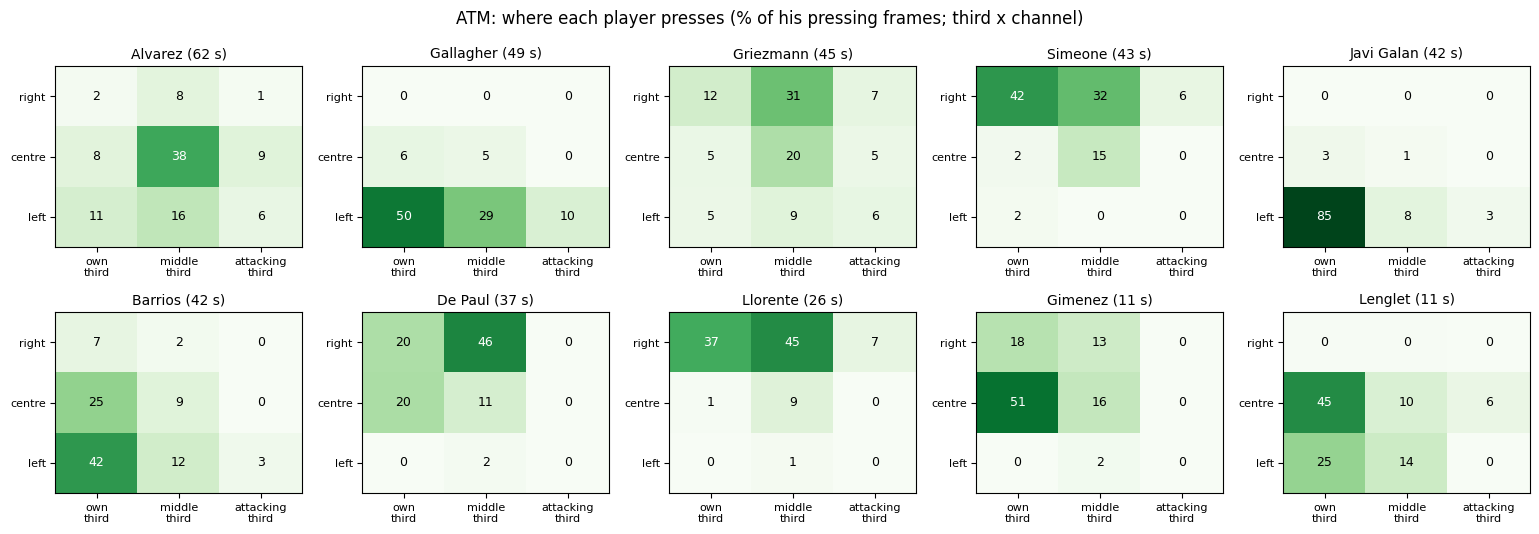

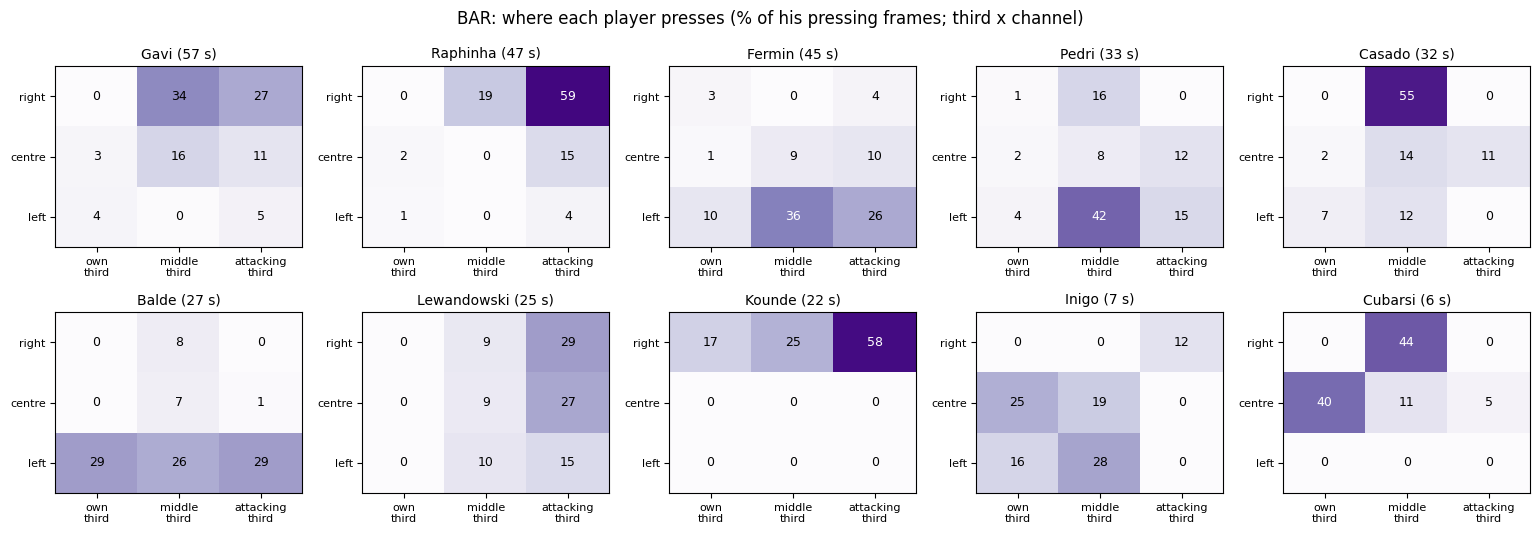

SUMMARY
  ATM: most of their pressing in the attacking third = Griezmann (18%), Alvarez (16%), Gallagher (10%); least = Gimenez (0%), De Paul (0%).
      most common cell per player: Alvarez: middle / centre; Gallagher: own / left; Griezmann: middle / right; Simeone: own / right; Javi Galan: own / left (top 5 by pressing time).
  BAR: most of their pressing in the attacking third = Raphinha (78%), Lewandowski (71%), Kounde (58%); least = Cubarsi (5%), Casado (11%).
      most common cell per player: Gavi: middle / right; Raphinha: attacking / right; Fermin: middle / left; Pedri: middle / left; Casado: middle / right (top 5 by pressing time).


In [19]:
d = player_press_frames()
pp = d[d["pressing"]].dropna(subset=["zone", "channel"])
cells = [(z, ch) for z in ZONES for ch in CH_ORDER]
col_name = lambda z, ch: f"{ZONE_SHORT[z]}_{CH_LABEL[ch]}"
minp = PRM["MIN_PLAYER_PRESS_FRAMES"]

rows = []
for (team, player), s in pp.groupby(["team", "player"]):
    n = len(s); row = dict(team=name(team), player=player, pressing_sec=round(n / FPS, 1), enough_data=n >= minp)
    cnt = s.groupby(["zone", "channel"]).size()
    for z, ch in cells:
        row[col_name(z, ch)] = round(100 * cnt.get((z, ch), 0) / n, 1)
    best = max(cells, key=lambda c: cnt.get(c, 0))
    row["main_cell"] = f"{best[0].replace('_third', '')} / {CH_LABEL[best[1]]}"
    row["pct_attacking_third"] = round(100 * (s["zone"] == "attacking_third").mean(), 1)
    rows.append(row)
t16 = pd.DataFrame(rows).sort_values(["team", "pressing_sec"], ascending=[True, False]).set_index(["team", "player"])
display(t16)

for team, cmap in zip(TEAMS[:2], ["Greens", "Purples"]):
    ts = t16.loc[name(team)]
    n_pl = len(ts); ncols = 5; nrows = int(np.ceil(n_pl / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 2.7 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, (player, r) in zip(axes.ravel(), ts.iterrows()):
        ax.axis("on")
        M = np.array([[r[col_name(z, ch)] for z in ZONES] for ch in CH_ORDER], dtype=float)
        if not r["enough_data"]:
            M = np.full((3, 3), np.nan)
        draw_grid(ax, M, [["" if np.isnan(M[i, j]) else f"{M[i, j]:.0f}" for j in range(3)] for i in range(3)],
                  f"{player} ({r['pressing_sec']:.0f} s)" + ("" if r["enough_data"] else "  few frames"), cmap=cmap, vmax=60)
    fig.suptitle(f"{name(team)}: where each player presses (% of his pressing frames; third x channel)", fontsize=12)
    plt.tight_layout(); plt.show()

print("SUMMARY")
for team in TEAMS:
    ts = t16.loc[name(team)]; ok = ts[ts["enough_data"]]
    if ok.empty:
        print(f"  {name(team)}: no player with enough pressing frames."); continue
    hi = ok.sort_values("pct_attacking_third", ascending=False).head(3)
    lo = ok.sort_values("pct_attacking_third").head(2)
    print(f"  {name(team)}: most of their pressing in the attacking third = " + ", ".join(f"{p} ({r['pct_attacking_third']:.0f}%)" for p, r in hi.iterrows())
          + "; least = " + ", ".join(f"{p} ({r['pct_attacking_third']:.0f}%)" for p, r in lo.iterrows()) + ".")
    print("      most common cell per player: " + "; ".join(f"{p}: {r['main_cell']}" for p, r in ok.sort_values("pressing_sec", ascending=False).head(5).iterrows()) + " (top 5 by pressing time).")